In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [11]:
df = pd.read_csv('IoTPond6.csv')
df.head()

,created_at,entry_id,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Population,Fish_Length(cm),Fish_Weight(g)
0,2021-06-19 00:01:46 UTC,1972.0,23.5000,30.0,0.723,9.02832,5.91560,285.0,75,7.3,3.2
1,2021-06-19 00:02:05 UTC,1973.0,23.5000,29.0,0.008,8.98746,5.80338,290.0,75,7.3,3.2
2,2021-06-19 00:05:01 UTC,1982.0,23.4375,29.0,1.365,9.04647,5.65000,302.0,75,7.3,3.2
3,2021-06-19 00:10:14 UTC,1998.0,23.4375,30.0,0.249,9.06009,5.54304,289.0,75,7.3,3.2
4,2021-06-19 00:35:35 UTC,2072.0,23.4375,30.0,1.892,9.11910,4.79604,297.0,75,7.3,3.2


In [12]:
print(df.isnull().sum())

created_at                 1
entry_id                  35
Temperature(C)            35
Turbidity(NTU)            35
Dissolved Oxygen(g/ml)    35
PH                        35
Ammonia(g/ml)             35
Nitrate(g/ml)             35
Population                 0
Fish_Length(cm)            0
Fish_Weight(g)             0
dtype: int64


In [13]:
df['Ammonia(g/ml)'].fillna(df['Ammonia(g/ml)'].mean(), inplace=True)
df['Turbidity(NTU)'].fillna(df['Turbidity(NTU)'].mean(), inplace=True)
df['Temperature(C)'].fillna(df['Temperature(C)'].mean(), inplace=True)
df['Dissolved Oxygen(g/ml)'].fillna(df['Dissolved Oxygen(g/ml)'].mean(), inplace=True)
df['PH'].fillna(df['PH'].mean(), inplace=True)
df['Nitrate(g/ml)'].fillna(df['Nitrate(g/ml)'].mean(), inplace=True)

In [14]:
df = df[df['created_at'].notnull()]

In [15]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [16]:
df.describe()

,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length(cm),Fish_Weight(g)
count,91049.000000,91049.000000,91049.000000,91049.000000,91049.00000,91049.000000,91049.000000,91049.000000
mean,24.507347,98.293193,10.406378,6.192765,inf,931.126660,18.604811,89.083698
std,0.940411,6.091926,8.928367,2.106152,NaN,758.752071,7.872148,87.150530
min,22.562500,8.000000,0.007000,-3.137450,0.00006,89.000000,7.300000,3.200000
25%,23.812500,99.000000,4.401000,5.360430,0.00106,272.000000,11.930000,15.800000
50%,24.312500,100.000000,7.498000,7.167130,5.21473,432.000000,17.360000,47.850000
75%,25.250000,100.000000,14.225000,7.566610,23.48226,1759.000000,28.740000,205.550000
max,28.062500,100.000000,44.635000,9.146340,inf,2871.000000,48.690000,786.600000


In [17]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [18]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [19]:
df.drop(["created_at"], axis = 1, inplace = True)

In [20]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [21]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [22]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [23]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [24]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [25]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [26]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [36]:
df.at[0,'PH']=8.5

In [38]:
df.index = df.index.astype(int)
for i in range(1, len(df)):
    if df.iloc[i, df.columns.get_loc("PH")] < 6 or df.iloc[i, df.columns.get_loc("PH")] > 8.5:
        df.iloc[i, df.columns.get_loc("PH")] = df.iloc[i-1, df.columns.get_loc("PH")]

In [41]:
df.at[0,'Dissolved Oxygen(g/ml)']=5

In [43]:
df.index = df.index.astype(int)
for i in range(1, len(df)):
    if df.iloc[i, df.columns.get_loc("Dissolved Oxygen(g/ml)")] < 5 or df.iloc[i, df.columns.get_loc("Dissolved Oxygen(g/ml)")] > 20:
        df.iloc[i, df.columns.get_loc("Dissolved Oxygen(g/ml)")] = df.iloc[i-1, df.columns.get_loc("Dissolved Oxygen(g/ml)")]

In [39]:
df["Ammonia(g/ml)"] = np.log(df["Ammonia(g/ml)"]) / 10.0
df["Ammonia(g/ml)"] = df["Ammonia(g/ml)"].abs()


In [40]:
df["Nitrate(g/ml)"] = df["Nitrate(g/ml)"].apply(np.sqrt)

In [44]:
df.describe()

,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length(cm),Fish_Weight(g),Date,month,year,hour,minutes,seconds
count,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000,91049.000000
mean,24.507347,98.293193,10.246400,6.962921,0.442909,27.839933,18.604811,89.083698,17.240222,7.481016,2021.000033,11.474777,29.608969,29.464563
std,0.940411,6.091926,4.344523,0.672158,0.232863,12.492658,7.872148,87.150530,7.415714,1.084086,0.005740,6.971960,17.337364,17.330930
min,22.562500,8.000000,5.000000,6.000490,0.000103,9.433981,7.300000,3.200000,1.000000,1.000000,2021.000000,0.000000,0.000000,0.000000
25%,23.812500,99.000000,6.457000,6.073120,0.263304,16.492423,11.930000,15.800000,14.000000,7.000000,2021.000000,5.000000,15.000000,14.000000
50%,24.312500,100.000000,8.984000,7.167130,0.377245,20.784610,17.360000,47.850000,19.000000,7.000000,2021.000000,12.000000,30.000000,29.000000
75%,25.250000,100.000000,13.661000,7.566610,0.684949,41.940434,28.740000,205.550000,22.000000,9.000000,2021.000000,18.000000,45.000000,44.000000
max,28.062500,100.000000,19.998000,8.500000,2.072327,53.581713,48.690000,786.600000,31.000000,12.000000,2022.000000,23.000000,59.000000,59.000000


In [45]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [46]:
df.head()

,Date,month,year,hour,minutes,seconds,Temperature(C),Turbidity(NTU),Dissolved Oxygen(g/ml),PH,Ammonia(g/ml),Nitrate(g/ml),Fish_Length(cm),Fish_Weight(g)
0,19,6,2021,0,1,46,23.5000,30.0,5.0,8.5,0.177759,16.881943,7.3,3.2
1,19,6,2021,0,2,5,23.5000,29.0,5.0,8.5,0.175844,17.029386,7.3,3.2
2,19,6,2021,0,5,1,23.4375,29.0,5.0,8.5,0.173166,17.378147,7.3,3.2
3,19,6,2021,0,10,14,23.4375,30.0,5.0,8.5,0.171254,17.000000,7.3,3.2
4,19,6,2021,0,35,35,23.4375,30.0,5.0,8.5,0.156779,17.233688,7.3,3.2


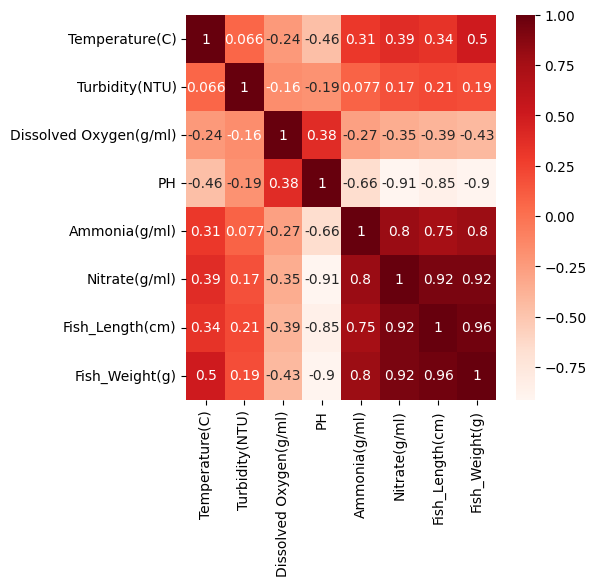

In [47]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [48]:
df.to_csv('pp6.csv', index=False)